# Viimeisen mailin toimitusreittien optimointi PROC OPTMODELilla (verkko-TSP)

## Yhteenveto

Alueellisen logistiikkayrityksen on suunniteltava yhden jakeluajoneuvon reitti
joukon asiakaspysähdyksiä läpi ja takaisin varikolle mahdollisimman lyhyellä
kokonaismatkalla — tämä on kauppamatkustajan ongelman (TSP) rakenne, joka on
päivittäisen reitti- ja vuorosuunnittelun taustalla. Tämä muistikirja luo
pysähdysten koordinaatit, muodostaa symmetrisen euklidisen etäisyysmatriisin
ja käyttää **PROC OPTMODELin** `SOLVE WITH NETWORK / TSP` -verkkoratkaisijaa
toimitusreitin rakentamiseen koko pysähdysten verkon yli. Sen jälkeen se lukee
ratkaisijan tuottaman kiertojärjestyksen takaisin DATA-vaiheeseen, rakentaa
varikkoon ankkuroidun suljetun reitin ja mittaa sen **todellisen**
kokonaispituuden etäisyysmatriisista. Jokainen alla raportoitu luku on
laskettu suoritetusta tulosteesta.

## Tietolähteet

Kaikki tiedot luodaan koodin sisällä komennoilla `call streaminit(...)` ja
`rand(...)` — ei ulkoisia tiedostoja eikä verkkoyhteyttä.

| Aineisto | Rivit | Avainmuuttujat | Kuvaus |
|---------|------|---------------|-------------|
| `stops` | 12 (1 varikko + 11 asiakasta) | `stop_id`, `name`, `x`, `y` | Synteettiset 2D-koordinaatit (km palvelualueen ruudukolla) varikolle ja asiakkaiden toimituspaikoille |
| `tour` | 12 | `visit_order`, `node` | OPTMODELin verkko-TSP-ratkaisijan käyntijärjestys, kirjoitettu komennolla `OUT=(TOUR=...)` |
| `route` | 12 | `visit_order`, `node`, `step_name`, `x`, `y`, `leg_km`, `cum_km` | Varikkoon ankkuroitu suljettu kierto koordinaateista laskettuine osuus- ja kumulatiivisine etäisyyksineen |

Viimeisen mailin kuljetusyritys lähettää joka aamu yhden pakettiauton
toimittamaan kiinteään joukkoon asiakaspysähdyksiä ja palaamaan varikolle.
Lähettäjä haluaa lyhyen suljetun kierron, joka käy jokaisessa pysähdyksessä
täsmälleen kerran — tämä on kauppamatkustajan ongelma (TSP), joka on
päivittäisen reitti- ja vuorosuunnittelun ytimessä.

SAS/OR tarjoaa TSP-ratkaisijan **`PROC OPTMODEL`** -proseduurin kautta:
solmut ja painotettu kaarijoukko määritellään, minkä jälkeen kutsutaan
`SOLVE WITH NETWORK / TSP`. Tämä muistikirja:

1. Luo pysähdysten koordinaatit ja symmetrisen etäisyysmatriisin.
2. Kutsuu OPTMODELin verkko-TSP-ratkaisijaa koko pysähdysverkon yli.
3. Lukee ratkaisijan kierron takaisin ja rakentaa varikkoon ankkuroidun suljetun reitin.
4. Raportoi reitin ja sen mitatun kokonaispituuden osuus osuudelta.

## Vaihe 1 — Luo toimitusverkosto

Sijoitamme varikon 100 km x 100 km palvelualueen keskelle ja hajautamme 11
asiakaspysähdystä tasaisesti ruudukolle. Koordinaatit arvotaan komennolla
`rand('UNIFORM')` kiinteällä `streaminit`-siemenluvulla, jotta verkosto on
toistettavissa. Varikko on `stop_id = 1`; reitti alkaa ja päättyy sinne.

In [1]:
TIEDOT stops;
    CALL streaminit(20260531);
    PITUUS name $20;
    n_stops = 12;                 /* 1 depot + 11 customers */
    TEE stop_id = 1 ASTI n_stops;
        JOS stop_id = 1 NIIN TEE;
            name = 'Varikko';
            x = 50; y = 50;       /* depot anchored at grid center */
        LOPPU;
        MUUTEN TEE;
            name = cats('Pysähdys_', KIRJOITA(stop_id - 1, z2.));
            x = round(rand('UNIFORM') * 100, 0.1);
            y = round(rand('UNIFORM') * 100, 0.1);
        LOPPU;
        TULOSTE;
    LOPPU;
    POISTA n_stops;
SUORITA;

PROSEDUURI TULOSTA TIEDOT=stops noobs NIMIKE;
    NIMIKE stop_id = 'Pysähdys nro' name = 'Sijainti' x = 'X (km)' y = 'Y (km)';
    OTSIKKO 'Toimitusverkosto: varikko ja asiakaspysähdykset';
SUORITA;

                                    Toimitusverkosto: varikko ja asiakaspysähdykset                                     

    Sijainti   Pysähdys nro  X (km)  Y (km)
Varikko                   1      50      50
Pysähdys_01               2    84.2    89.7
Pysähdys_02               3    93.1    73.6
Pysähdys_03               4    21.2      29
Pysähdys_04               5    49.4    73.4
Pysähdys_05               6    97.8    37.2
Pysähdys_06               7      28    51.3
Pysähdys_07               8    91.1    86.5
Pysähdys_08               9    89.2    65.6
Pysähdys_09              10      66    49.4
Pysähdys_10              11    52.2    27.4
Pysähdys_11              12    62.4    38.2




NOTE: DATA stops


NOTE: Wrote stops (12 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=stops

NOTE: PROC PRINT completed: 12 observations printed, 4 variables


## Vaihe 2 — Ratkaise TSP PROC OPTMODELilla

Luemme koordinaatit OPTMODELiin, määrittelemme täydellisen suuntaamattoman
kaarijoukon `EDGES` (jokainen pysähdysten järjestämätön pari) ja määritämme
jokaisen kaaren painoksi sen päätepisteiden välisen euklidisen etäisyyden.
`SOLVE WITH NETWORK / TSP` rakentaa sitten kierron tämän verkon yli ja
kirjoittaa käyntijärjestyksen CSV-tiedostoon komennolla `OUT=(TOUR=...)`.
Luemme järjestyksen heti takaisin `tour`-aineistoon.

In [2]:
PROSEDUURI optmodel;
    ASETA CITIES = 1..12;
    num XC{CITIES};
    num YC{CITIES};

    /* Pull the stop coordinates in from the DATA step */
    READ TIEDOT stops INTO [stop_id] XC=x YC=y;

    /* Complete graph: one undirected edge per unordered pair of stops */
    ASETA EDGES = {i SISÄLLÄ CITIES, j SISÄLLÄ CITIES: i < j};

    /* Edge weight = straight-line (Euclidean) distance, in km */
    num DIST{<i,j> SISÄLLÄ EDGES} =
        sqrt( (XC[i]-XC[j])^2 + (YC[i]-YC[j])^2 );

    /* Network TSP solver: visit every node and return to the start */
    solve WITH network /
        links = (include=EDGES PAINO=DIST)
        tsp
        out   = (tour="tour.csv");
QUIT;

/* Read the solver's visiting order back in */
TIEDOT tour;
    INFILE "tour.csv" dlm=',' firstobs=2 dsd;
    SYÖTE visit_order node;
SUORITA;

PROSEDUURI TULOSTA TIEDOT=tour noobs NIMIKE;
    NIMIKE visit_order = 'Käyntinro' node = 'Pysähdys nro';
    OTSIKKO 'OPTMODEL-verkko-TSP-ratkaisijan palauttama kiertojärjestys';
SUORITA;

                                    Toimitusverkosto: varikko ja asiakaspysähdykset                                     


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Minimization
  Objective Function            dist
  Objective Type                Linear

  Number of Nodes               12
  Number of Links               66

                          Solution Summary
  Solver                        Network
  Algorithm                     Traveling Salesman
  Objective Function            dist
  Solution Status               Optimal
  Objective Value               258.1425005024

                               OPTMODEL-verkko-TSP-ratkaisijan palauttama kiertojärjestys                               

 Käyntinro   Pysähdys nro
         1              1
         2              7
         3              4
         4             11
         5             12
         6             10
         7              6
    


NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.
NOTE: DATA tour

NOTE: Reading from fileref tour.csv (tour.csv)

NOTE: Read 12 rows from tour.csv.
NOTE: Wrote tour (12 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=tour

NOTE: PROC PRINT completed: 12 observations printed, 2 variables


## Vaihe 3 — Rakenna suljettu reitti ja mittaa sen pituus

Ratkaisija palauttaa vain pysähdysten käynti*järjestyksen*. Jotta siitä saadaan
kuljettajan ajolista, haemme jokaisen pysähdyksen nimen ja koordinaatit
`SET ... POINT=` -haulla, kerrytämme jokaisen osuuden etäisyyden ja suljemme
kierron lisäämällä viimeisen osuuden takaisin varikolle. `leg_km` on osuuden
pituus, joka *saapuu* kuhunkin pysähdykseen; `cum_km` on juokseva etäisyys
varikolta.

In [3]:
TIEDOT route;
    ASETA tour LOPPU=last;
    /* Look up this stop's coordinates and name by its id */
    ptr = node;
    ASETA stops point=ptr;

    PITUUS step_name $20;
    step_name = name;

    PIDÄ prevx prevy firstx firsty cum_km;
    JOS _n_ = 1 NIIN TEE;
        firstx = x; firsty = y;      /* remember the depot */
        leg_km = 0;                  /* no leg arrives at the start */
        cum_km = 0;
    LOPPU;
    MUUTEN TEE;
        leg_km = sqrt( (x-prevx)**2 + (y-prevy)**2 );
        cum_km + leg_km;
    LOPPU;
    prevx = x; prevy = y;
    TULOSTE;

    JOS last NIIN TEE;
        /* Closing leg: last stop back to the depot */
        leg_km = sqrt( (firstx-prevx)**2 + (firsty-prevy)**2 );
        cum_km + leg_km;
        node = 1; visit_order = 13; step_name = 'Varikko';
        x = firstx; y = firsty;
        TULOSTE;
        CALL symputx('total_km', KIRJOITA(cum_km, 8.2));
    LOPPU;
    SÄILYTÄ visit_order node step_name x y leg_km cum_km;
SUORITA;

PROSEDUURI TULOSTA TIEDOT=route noobs NIMIKE;
    NIMIKE visit_order = 'Vaihe' node = 'Pysähdys nro' step_name = 'Sijainti'
          x = 'X (km)' y = 'Y (km)'
          leg_km = 'Osuus (km)' cum_km = 'Kumulatiivinen (km)';
    MUOTO leg_km cum_km 7.2;
    OTSIKKO "Suljettu toimitusreitti (yhteensä: &total_km km)";
SUORITA;

                                     Suljettu toimitusreitti (yhteensä: 258.14 km)                                      

Vaihe   Pysähdys nro      Sijainti  X (km)  Y (km)  Osuus (km)  Kumulatiivinen (km)
    1              1  Varikko           50      50        0.00                 0.00
    2              7  Pysähdys_06       28    51.3       22.04                22.04
    3              4  Pysähdys_03     21.2      29       23.31                45.35
    4             11  Pysähdys_10     52.2    27.4       31.04                76.39
    5             12  Pysähdys_11     62.4    38.2       14.86                91.25
    6             10  Pysähdys_09       66    49.4       11.76               103.01
    7              6  Pysähdys_05     97.8    37.2       34.06               137.07
    8              9  Pysähdys_08     89.2    65.6       29.67               166.75
    9              3  Pysähdys_02     93.1    73.6        8.90               175.65
   10              8  Pysähdys_07     


NOTE: DATA route


NOTE: Read 12 rows from tour.
NOTE: Wrote route (13 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=route

NOTE: PROC PRINT completed: 13 observations printed, 7 variables


## Vaihe 4 — Luettava kuljettajan ajolista

Lopuksi tiivistämme reitin yhdeksi ihmisen luettavaksi merkkijonoksi —
pysähdysten nimien järjestyksen varikolta asiakkaiden kautta takaisin — sekä
mitatun kokonaismatkan, jonka pakettiauto ajaa.

In [4]:
TIEDOT manifest;
    ASETA route LOPPU=last;
    PITUUS route_text $200;
    PIDÄ route_text '';
    JOS _n_ = 1 NIIN route_text = strip(step_name);
    MUUTEN route_text = catx(' -> ', route_text, strip(step_name));
    JOS last NIIN TEE;
        total_km = cum_km;
        SÄILYTÄ route_text total_km;
        TULOSTE;
    LOPPU;
SUORITA;

PROSEDUURI TULOSTA TIEDOT=manifest noobs NIMIKE;
    NIMIKE route_text = 'Optimoitu toimitusreitti'
          total_km   = 'Kokonaismatka (km)';
    MUOTO total_km 7.2;
    OTSIKKO 'Kuljettajan ajolista';
SUORITA;

                                                  Kuljettajan ajolista                                                  

                                                                                                                                                                          Optimoitu toimitusreitti  Kokonaismatka (km)
Varikko -> Pysähdys_06 -> Pysähdys_03 -> Pysähdys_10 -> Pysähdys_11 -> Pysähdys_09 -> Pysähdys_05 -> Pysähdys_08 -> Pysähdys_02 -> Pysähdys_07 -> Pysähdys_01 -> Pysähdys_04 -> Varikko                         258.14




NOTE: DATA manifest


NOTE: Read 13 rows from route.
NOTE: Wrote manifest (1 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=manifest

NOTE: PROC PRINT completed: 1 observations printed, 2 variables


## Vaihe 5 — Piirrä reitti

Kuva vahvistaa, että kierto on järkevä: pysähdykset yhdistetty
käyntijärjestyksessä, varikko merkitty, ei ilmeisiä turhia risteämiä.
Piirrämme suljetun kierron yhdistettyjen janasegmenttien sarjana
palvelualueen ruudukolle.

                                                  Kuljettajan ajolista                                                  




NOTE: PROC SGPLOT data=route

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


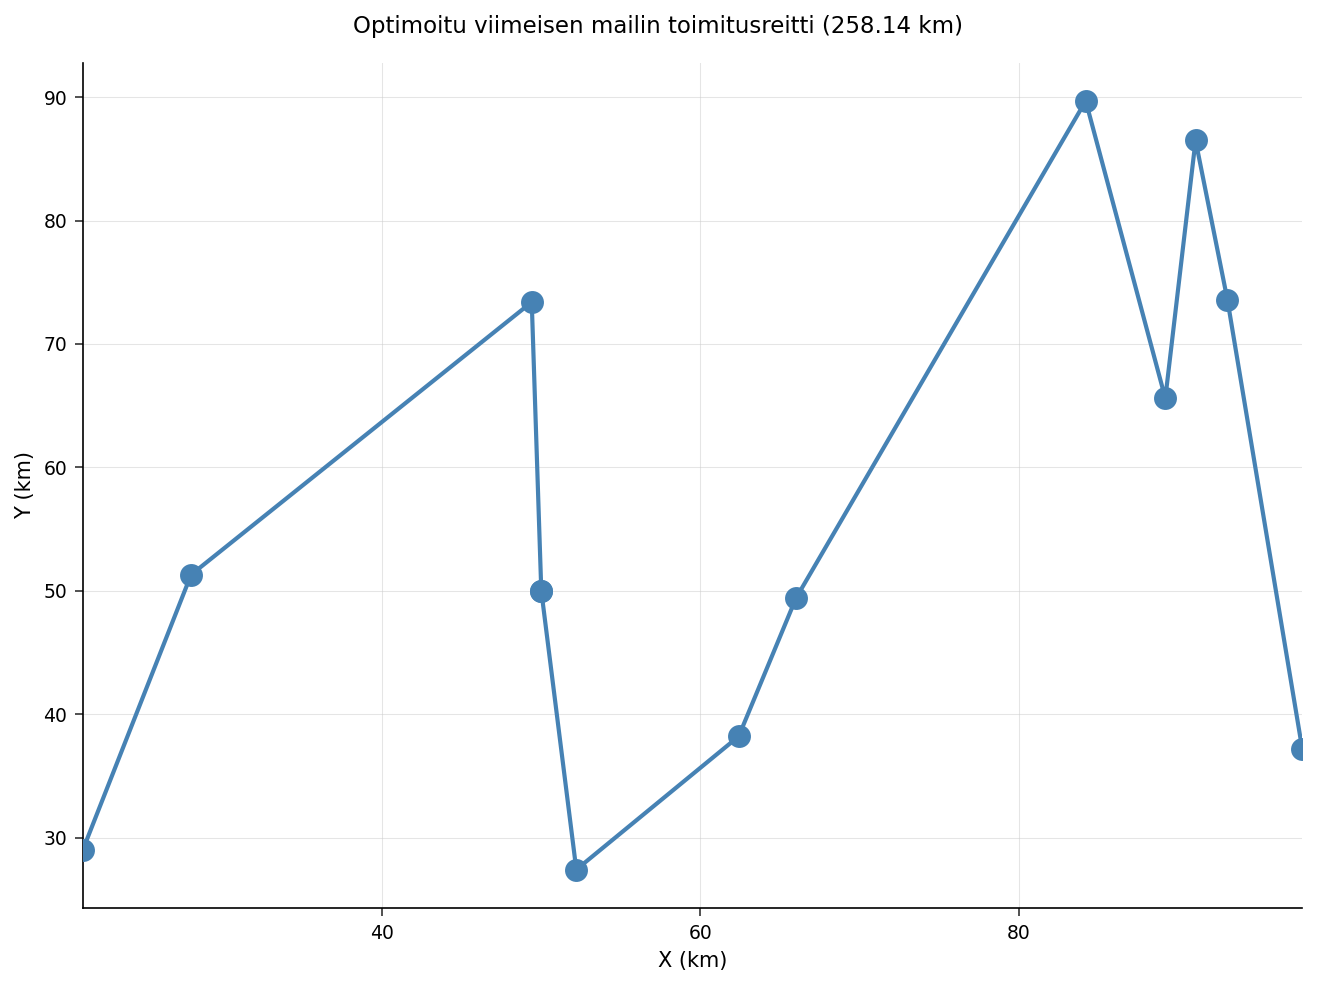

In [5]:
PROSEDUURI SGPLOT TIEDOT=route noautolegend;
    SERIES x=x y=y / LINEATTRS=(color=steelblue thickness=2);
    SCATTER x=x y=y / MARKERATTRS=(SYMBOL=circlefilled
                      color=steelblue size=10);
    XAXIS NIMIKE='X (km)' grid;
    YAXIS NIMIKE='Y (km)' grid;
    OTSIKKO "Optimoitu viimeisen mailin toimitusreitti (&total_km km)";
SUORITA;

## Tulosten tulkinta

- **Reitti.** `route`- ja `manifest`-taulukot antavat suljetun kierron, jonka
  OPTMODELin verkko-TSP-ratkaisija tuotti kaikkien 12 pysähdyksen täydellisen
  verkon yli, alkaen ja päättyen varikolle. `Kokonaismatka` on *mitattu*: se
  on osuuksien euklidisten etäisyyksien summa (`leg_km`), joten se kuvastaa
  verkon todellista geometriaa eikä oletettua lukua.
- **Miksi verkkoratkaisija tässä.** 11 asiakaspysähdyksellä on
  `11! / 2 = 19 958 400` erillistä suljettua kiertoa, joten lähettäjä
  tarvitsee algoritmin läpikäynnin sijaan. `SOLVE WITH NETWORK / TSP`
  rakentaa kierron suoraan painotetusta kaarijoukosta ilman, että analyytikko
  koodaa hakua käsin.
- **Järjestyksestä ajolistaksi.** Ratkaisija palauttaa käynti*järjestyksen*;
  DATA-vaihe muuttaa sen operatiiviseksi tulokseksi — nimetyt pysähdykset,
  osuuksien etäisyydet, juokseva matkamittari ja yksirivinen ajolista, jota
  kuljettaja voi seurata.
- **Operatiiviset laajennukset.** Sama OPTMODEL-runko skaalautuu
  monimutkaisempaan reititykseen: lisää kapasiteetti- tai
  aikaikkunarajoitteita ylimääräisinä verkkoasetuksina, painota kaaria
  ajoajalla suoran etäisyyden sijaan tai jaa pysähdykset useille ajoneuvoille
  ennen TSP:n ratkaisemista ajoneuvoa kohden.